# DPLQR trajectory diagnostic: no early stopping

This notebook launches the independent command-line implementation in `scripts/run_trajectory.py` and displays its results. The model and original DGP are reused from the repository. Each replicate follows one continuous, unclipped training path; validation/test data never choose weights or change training.

The **intended experiment is 100 repetitions per case and 1,000 epochs**. The editable launcher below defaults to the already supplied two-repetition smoke test. Set `REPETITIONS = 100`, `MAX_EPOCHS = 1000`, `WORKERS = 6`, and `OUTPUT_DIR = EXPERIMENT_DIR` to run/resume the intended experiment. Run cells in order with the repository `.venv` kernel. There is no dependency on the deleted `simulate_homoscedastic.py`.

In [1]:
import sys, subprocess
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image
cwd = Path.cwd().resolve()
ROOT = next((p for p in (cwd,*cwd.parents) if (p/'dqAux.py').is_file()),None)
if ROOT is None:
    raise FileNotFoundError('Start this notebook inside the dplqr repository.')
EXPERIMENT_DIR = ROOT/'results/2026-09-08-epoch-trajectory-no-early-stopping'
SCRIPT = EXPERIMENT_DIR/'scripts/run_trajectory.py'
REPETITIONS = 2
MAX_EPOCHS = 50
WORKERS = 3
OUTPUT_DIR = EXPERIMENT_DIR/'smoke-test'
print('Interpreter:',sys.executable)
print('Active profile:',REPETITIONS,'repetitions per case;',MAX_EPOCHS,'epochs')

Interpreter: C:\Users\Tiansui Tu\Documents\GitHub\dplqr\.venv\Scripts\python.exe
Active profile: 2 repetitions per case; 50 epochs


## Run or resume
The same command works from a terminal; `--repetitions` controls the Monte Carlo design. Existing completed paths are reused only when their settings and source identity match. An interrupted replicate restarts from its fixed seeds. Each worker owns separate data, network and optimizer state.

In [2]:
command = [sys.executable,str(SCRIPT),'--repetitions',str(REPETITIONS),
           '--max-epochs',str(MAX_EPOCHS),'--workers',str(WORKERS),'--output-dir',str(OUTPUT_DIR)]
with subprocess.Popen(command,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True,errors='replace') as process:
    for line in process.stdout:
        print(line,end='')
    result = process.wait()
if result:
    raise subprocess.CalledProcessError(result,command)

Completed 1/6: case=1 replicate=1 fit=1.6s cached=True elapsed=2.3s
Completed 2/6: case=1 replicate=2 fit=1.6s cached=True elapsed=2.3s
Completed 3/6: case=2 replicate=1 fit=1.6s cached=True elapsed=2.3s
Completed 4/6: case=2 replicate=2 fit=1.5s cached=True elapsed=2.3s
Completed 5/6: case=3 replicate=1 fit=1.4s cached=True elapsed=2.3s
Completed 6/6: case=3 replicate=2 fit=1.5s cached=True elapsed=2.3s


Complete: 42 rows, 6 continuous paths; 12.8s


## Numerical verification
This checks checkpoint integrity, continuous optimizer steps, finite labeled quantities, Monte Carlo formulas, and independently recomputes selected checkpoint diagnostics from their saved weights and data seeds.

In [3]:
subprocess.run([sys.executable,str(EXPERIMENT_DIR/'scripts/verify_outputs.py'),str(OUTPUT_DIR)],check=True)

CompletedProcess(args=['C:\\Users\\Tiansui Tu\\Documents\\GitHub\\dplqr\\.venv\\Scripts\\python.exe', 'C:\\Users\\Tiansui Tu\\Documents\\GitHub\\dplqr\\results\\2026-09-08-epoch-trajectory-no-early-stopping\\scripts\\verify_outputs.py', 'C:\\Users\\Tiansui Tu\\Documents\\GitHub\\dplqr\\results\\2026-09-08-epoch-trajectory-no-early-stopping\\smoke-test'], returncode=0)

## Results
The Monte Carlo summaries are primary. The preselected individual paths illustrate behavior and are not selected for an interesting effect. L2 error here means the square root of mean squared error; it differs from the paper's relative-MSE table metric.

,case,case_name,epoch,theta_component,theta_true,mean_theta,bias,sd,rmse,mae,bias_mcse,repetitions,mc_sd_available
0,1,linear,1,theta_1,1.0,0.116911,-0.883089,0.723660,1.020631,0.883089,0.511705,2,True
1,1,linear,1,theta_2,-1.0,-0.062072,0.937928,0.827483,1.105474,0.937928,0.585119,2,True
2,1,linear,2,theta_1,1.0,0.151744,-0.848256,0.723761,0.990683,0.848256,0.511776,2,True
3,1,linear,2,theta_2,-1.0,-0.027258,0.972742,0.827333,1.135106,0.972742,0.585013,2,True
4,1,linear,5,theta_1,1.0,0.232115,-0.767885,0.733917,0.926804,0.767885,0.518958,2,True
5,1,linear,5,theta_2,-1.0,0.039997,1.039997,0.803480,1.185067,1.039997,0.568146,2,True
6,1,linear,10,theta_1,1.0,0.301717,-0.698283,0.702426,0.856913,0.698283,0.496690,2,True
7,1,linear,10,theta_2,-1.0,0.045982,1.045982,0.784765,1.184064,1.045982,0.554913,2,True
8,1,linear,20,theta_1,1.0,0.416653,-0.583347,0.619795,0.729635,0.583347,0.438261,2,True
9,1,linear,20,theta_2,-1.0,-0.040829,0.959171,0.717962,1.085239,0.959171,0.507676,2,True


# Continued-training diagnostic results

These results follow one initialized DPLQR model continuously on one training dataset per replicate. Training uses the fixed epoch ceiling, with no early stopping, no best-validation weight restoration, and no checkpoint selection. Validation, test and evaluation data do not affect optimization.

Completed data: **Case 1: 2 repetitions; Case 2: 2 repetitions; Case 3: 2 repetitions**; n = 1000; tau = 0.5; training/validation sizes = 800/200; independent test size = 10000; independent evaluation size = 10000.

Recorded epochs: 1, 2, 5, 10, 20, 30, 50. There are 42 checkpoint rows and 6 distinct case–replicate trajectories.

**This is a reduced run. The intended design is 100 repetitions per case; the current run does not complete that design.** Small-run differences and Monte Carlo uncertainty intervals are exploratory.

## Paired endpoint comparisons

The following comparisons use epoch **1 → 50** on the same replicate. Changes are end minus start. The coefficient diagnostic is the Euclidean error `||theta_hat - theta_true||_2`; it is not the absolute value of average bias.

### Coefficient L2 error

| Case | Mean at 1 | Mean at 50 | Mean paired change | MCSE of change | Approx. MC interval |
| --- | --- | --- | --- | --- | --- |
| Case 1 | 1.2887 | 0.7024 | -0.5864 | 0.3656 | [-1.3029, 0.1302] |
| Case 2 | 1.7389 | 0.8511 | -0.8879 | 0.0358 | [-0.9580, -0.8177] |
| Case 3 | 1.2921 | 0.5133 | -0.7788 | 0.0987 | [-0.9721, -0.5854] |

### Training check loss

| Case | Mean at 1 | Mean at 50 | Mean paired change | MCSE of change | Approx. MC interval |
| --- | --- | --- | --- | --- | --- |
| Case 1 | 1.9685 | 0.5413 | -1.4273 | 0.2508 | [-1.9188, -0.9357] |
| Case 2 | 2.1983 | 0.5341 | -1.6642 | 0.0070 | [-1.6778, -1.6505] |
| Case 3 | 0.9173 | 0.5133 | -0.4039 | 0.0005 | [-0.4048, -0.4030] |

### Independent test check loss

| Case | Mean at 1 | Mean at 50 | Mean paired change | MCSE of change | Approx. MC interval |
| --- | --- | --- | --- | --- | --- |
| Case 1 | 1.9439 | 0.5946 | -1.3493 | 0.2560 | [-1.8510, -0.8476] |
| Case 2 | 2.2182 | 0.6262 | -1.5920 | 0.0493 | [-1.6885, -1.4954] |
| Case 3 | 0.9006 | 0.6092 | -0.2914 | 0.0203 | [-0.3312, -0.2516] |

### Nuisance L2 error

| Case | Mean at 1 | Mean at 50 | Mean paired change | MCSE of change | Approx. MC interval |
| --- | --- | --- | --- | --- | --- |
| Case 1 | 4.6247 | 0.6167 | -4.0080 | 0.4230 | [-4.8370, -3.1789] |
| Case 2 | 5.0129 | 0.6409 | -4.3719 | 0.0031 | [-4.3780, -4.3659] |
| Case 3 | 2.3121 | 0.7690 | -1.5431 | 0.1325 | [-1.8028, -1.2835] |

### Full conditional-quantile L2 error

| Case | Mean at 1 | Mean at 50 | Mean paired change | MCSE of change | Approx. MC interval |
| --- | --- | --- | --- | --- | --- |
| Case 1 | 4.1788 | 0.4810 | -3.6979 | 0.6098 | [-4.8931, -2.5026] |
| Case 2 | 4.7245 | 0.6746 | -4.0499 | 0.0827 | [-4.2120, -3.8878] |
| Case 3 | 1.7665 | 0.6287 | -1.1378 | 0.0694 | [-1.2738, -1.0019] |

The intervals are mean paired change ± 1.96 × its Monte Carlo SE, treating a replicate as the independent unit. They are pointwise normal approximations, not simultaneous intervals or tests adjusted for looking across cases, coefficients and epochs. In small runs they can be unreliable. Evaluation-sample approximation error is also part of each replicate's measurement.

### Counts of paired directional changes

| Case | Q | Train loss ↓ | Theta L2 ↑ | q L2 ↓ | Test loss ↑ | Train ↓, theta ↑, q ↓ | Train ↓, theta ↑, test ↑ |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Case 1 | 2 | 2 | 0 | 2 | 0 | 0 | 0 |
| Case 2 | 2 | 2 | 0 | 2 | 0 | 0 | 0 |
| Case 3 | 2 | 2 | 0 | 2 | 0 | 0 | 0 |

These are literal strict directional comparisons of finite-sample estimates, without a post hoc threshold for 'roughly stable'. Counts alone do not establish a population effect. A lower q error with a worse coefficient estimate is compatible with compensation by the nuisance network; a negative cross-error moment directly describes cancellation on the evaluation sample. Neither observation alone establishes a causal or asymptotic mechanism. Worsening test loss alongside lower training loss is evidence compatible with ordinary prediction overfitting, which can coexist with compensation.

## Coefficient bias and RMSE

| Case | Component | Epoch | Mean estimate | Truth | Bias | SD | RMSE |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | theta_1 | 1 | 0.1169 | 1.0000 | -0.8831 | 0.7237 | 1.0206 |
| 1 | theta_2 | 1 | -0.0621 | -1.0000 | 0.9379 | 0.8275 | 1.1055 |
| 1 | theta_1 | 50 | 0.7299 | 1.0000 | -0.2701 | 0.3532 | 0.3679 |
| 1 | theta_2 | 50 | -0.3624 | -1.0000 | 0.6376 | 0.4905 | 0.7258 |
| 2 | theta_1 | 1 | -0.3813 | 1.0000 | -1.3813 | 0.0927 | 1.3828 |
| 2 | theta_2 | 1 | 0.0564 | -1.0000 | 1.0564 | 0.0795 | 1.0579 |
| 2 | theta_1 | 50 | 0.4502 | 1.0000 | -0.5498 | 0.0412 | 0.5506 |
| 2 | theta_2 | 50 | -0.3504 | -1.0000 | 0.6496 | 0.0585 | 0.6510 |
| 3 | theta_1 | 1 | 0.3540 | 1.0000 | -0.6460 | 0.1444 | 0.6540 |
| 3 | theta_2 | 1 | 0.1180 | -1.0000 | 1.1180 | 0.1159 | 1.1210 |
| 3 | theta_1 | 50 | 0.9619 | 1.0000 | -0.0381 | 0.1225 | 0.0946 |
| 3 | theta_2 | 50 | -0.4953 | -1.0000 | 0.5047 | 0.0243 | 0.5050 |

Bias is the mean signed coefficient error. SD uses the sample standard deviation across replicates (ddof = 1). RMSE is sqrt(mean squared coefficient error). Small bias can coexist with large SD or RMSE because positive and negative errors cancel across replicates.



### A theta bias

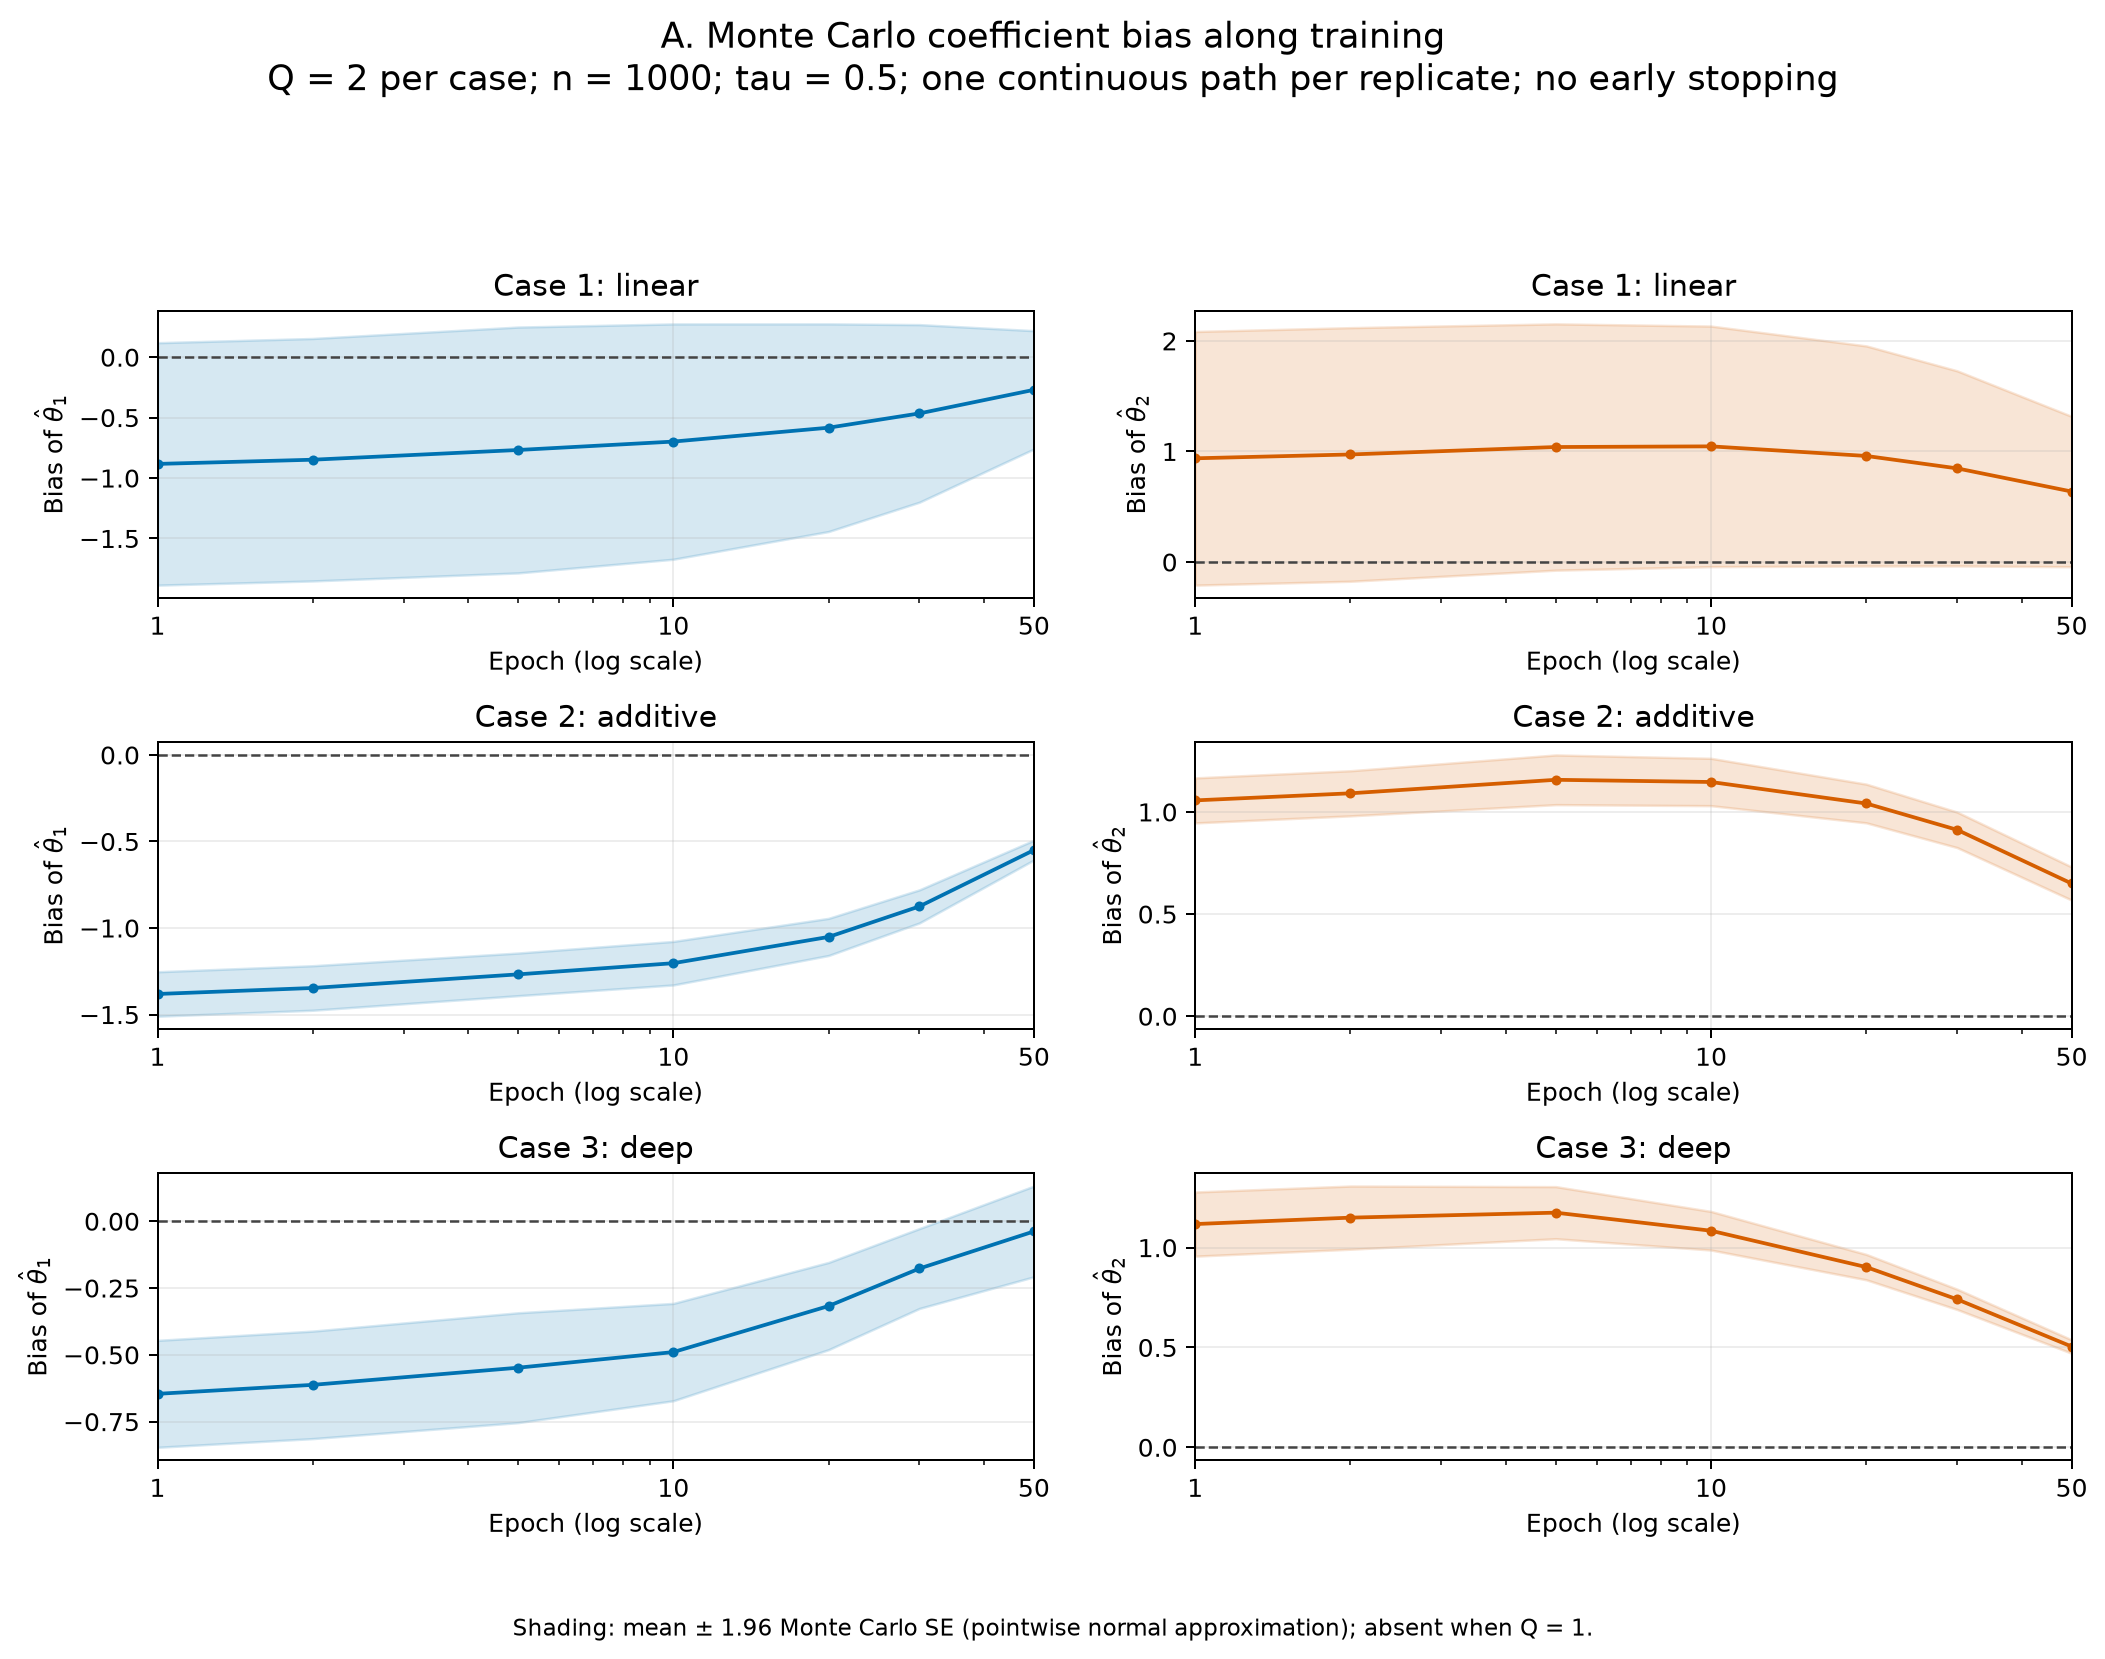

### B theta error

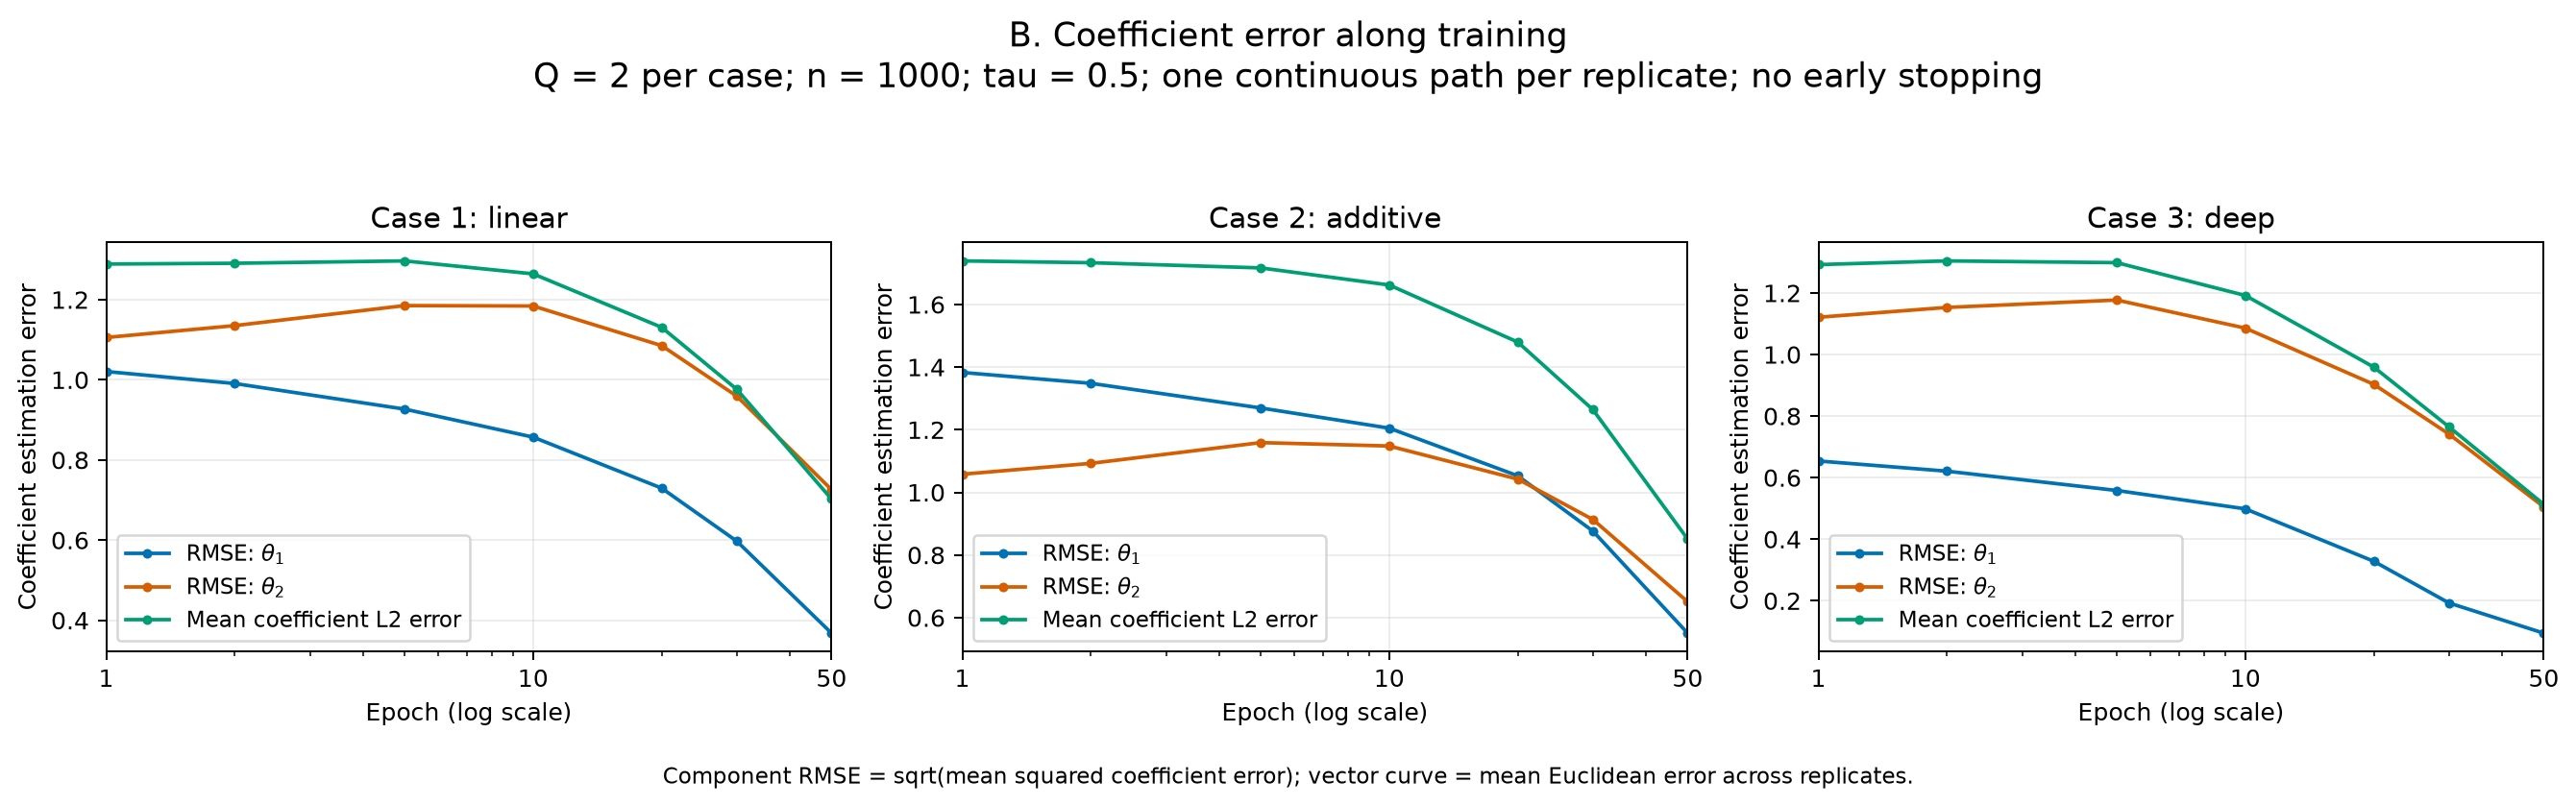

### C check loss

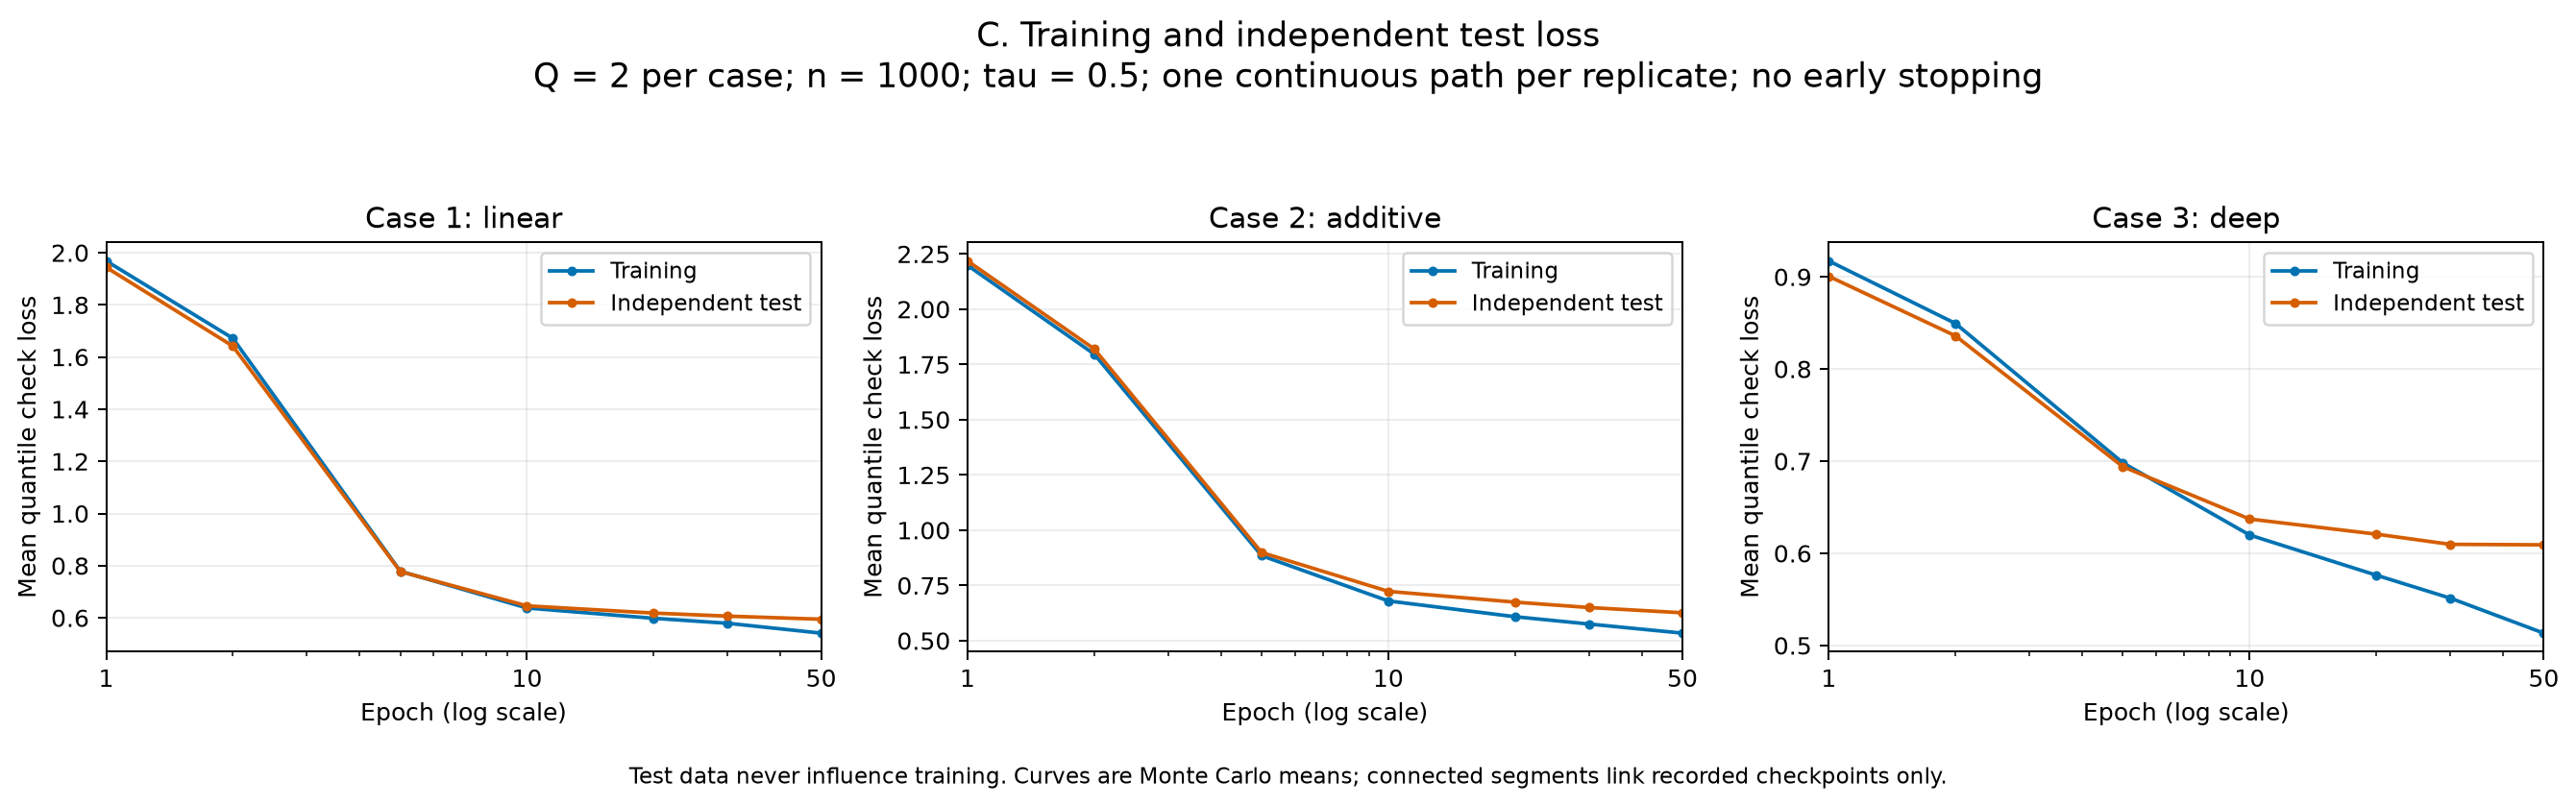

### D nuisance and quantile error

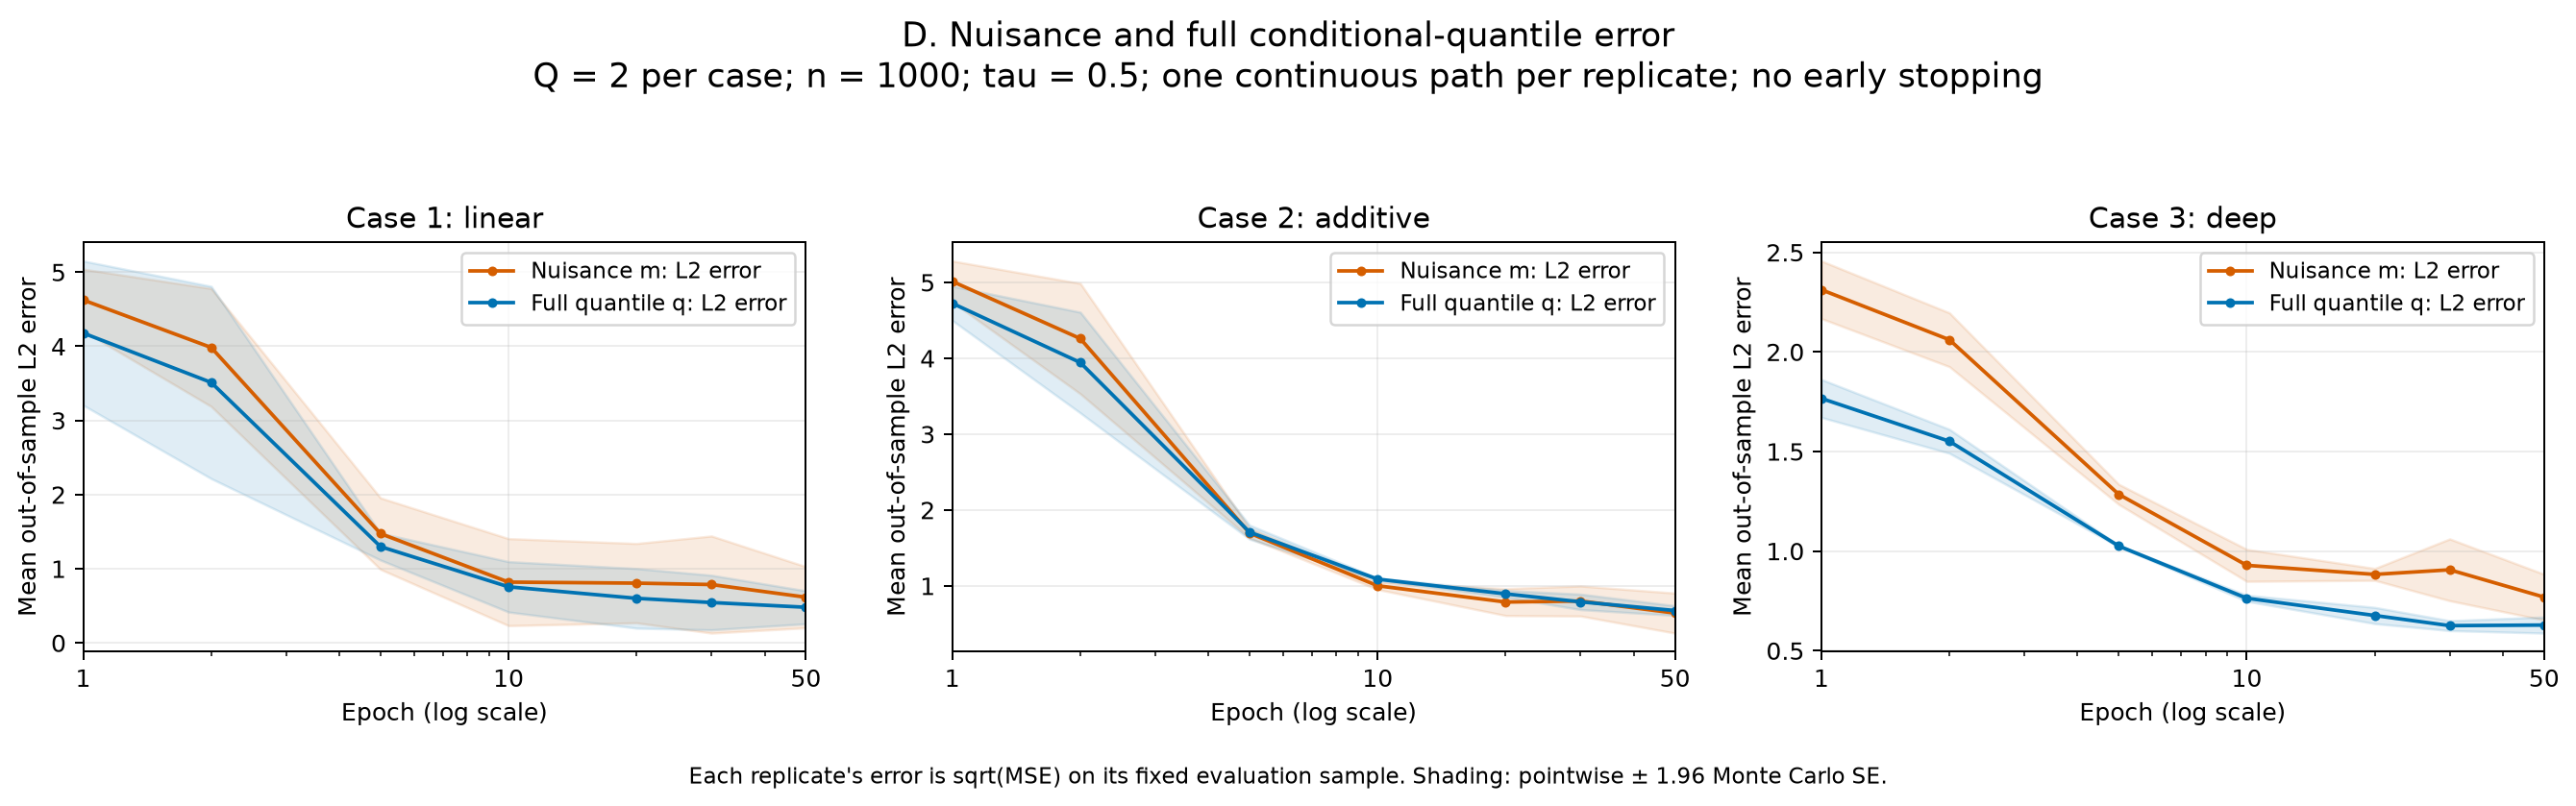

### E error decomposition

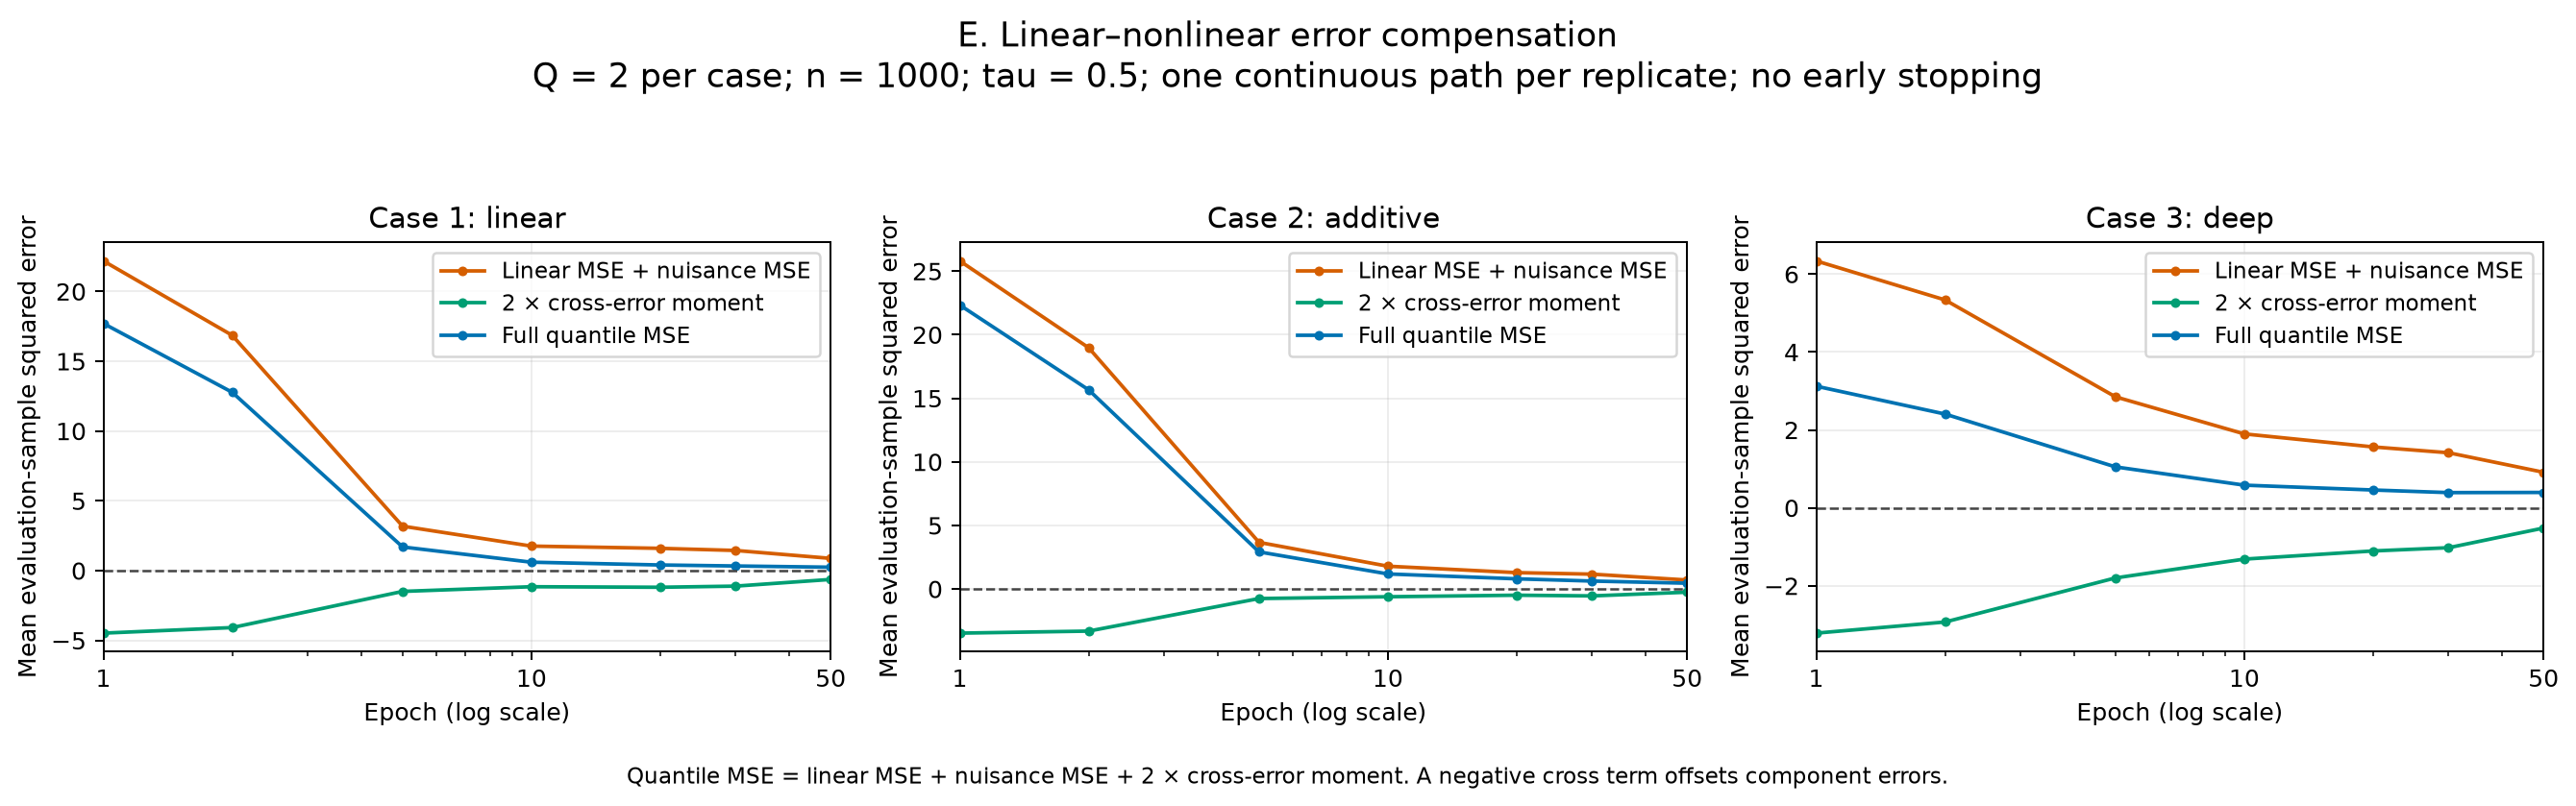

### F fixed replicate paths

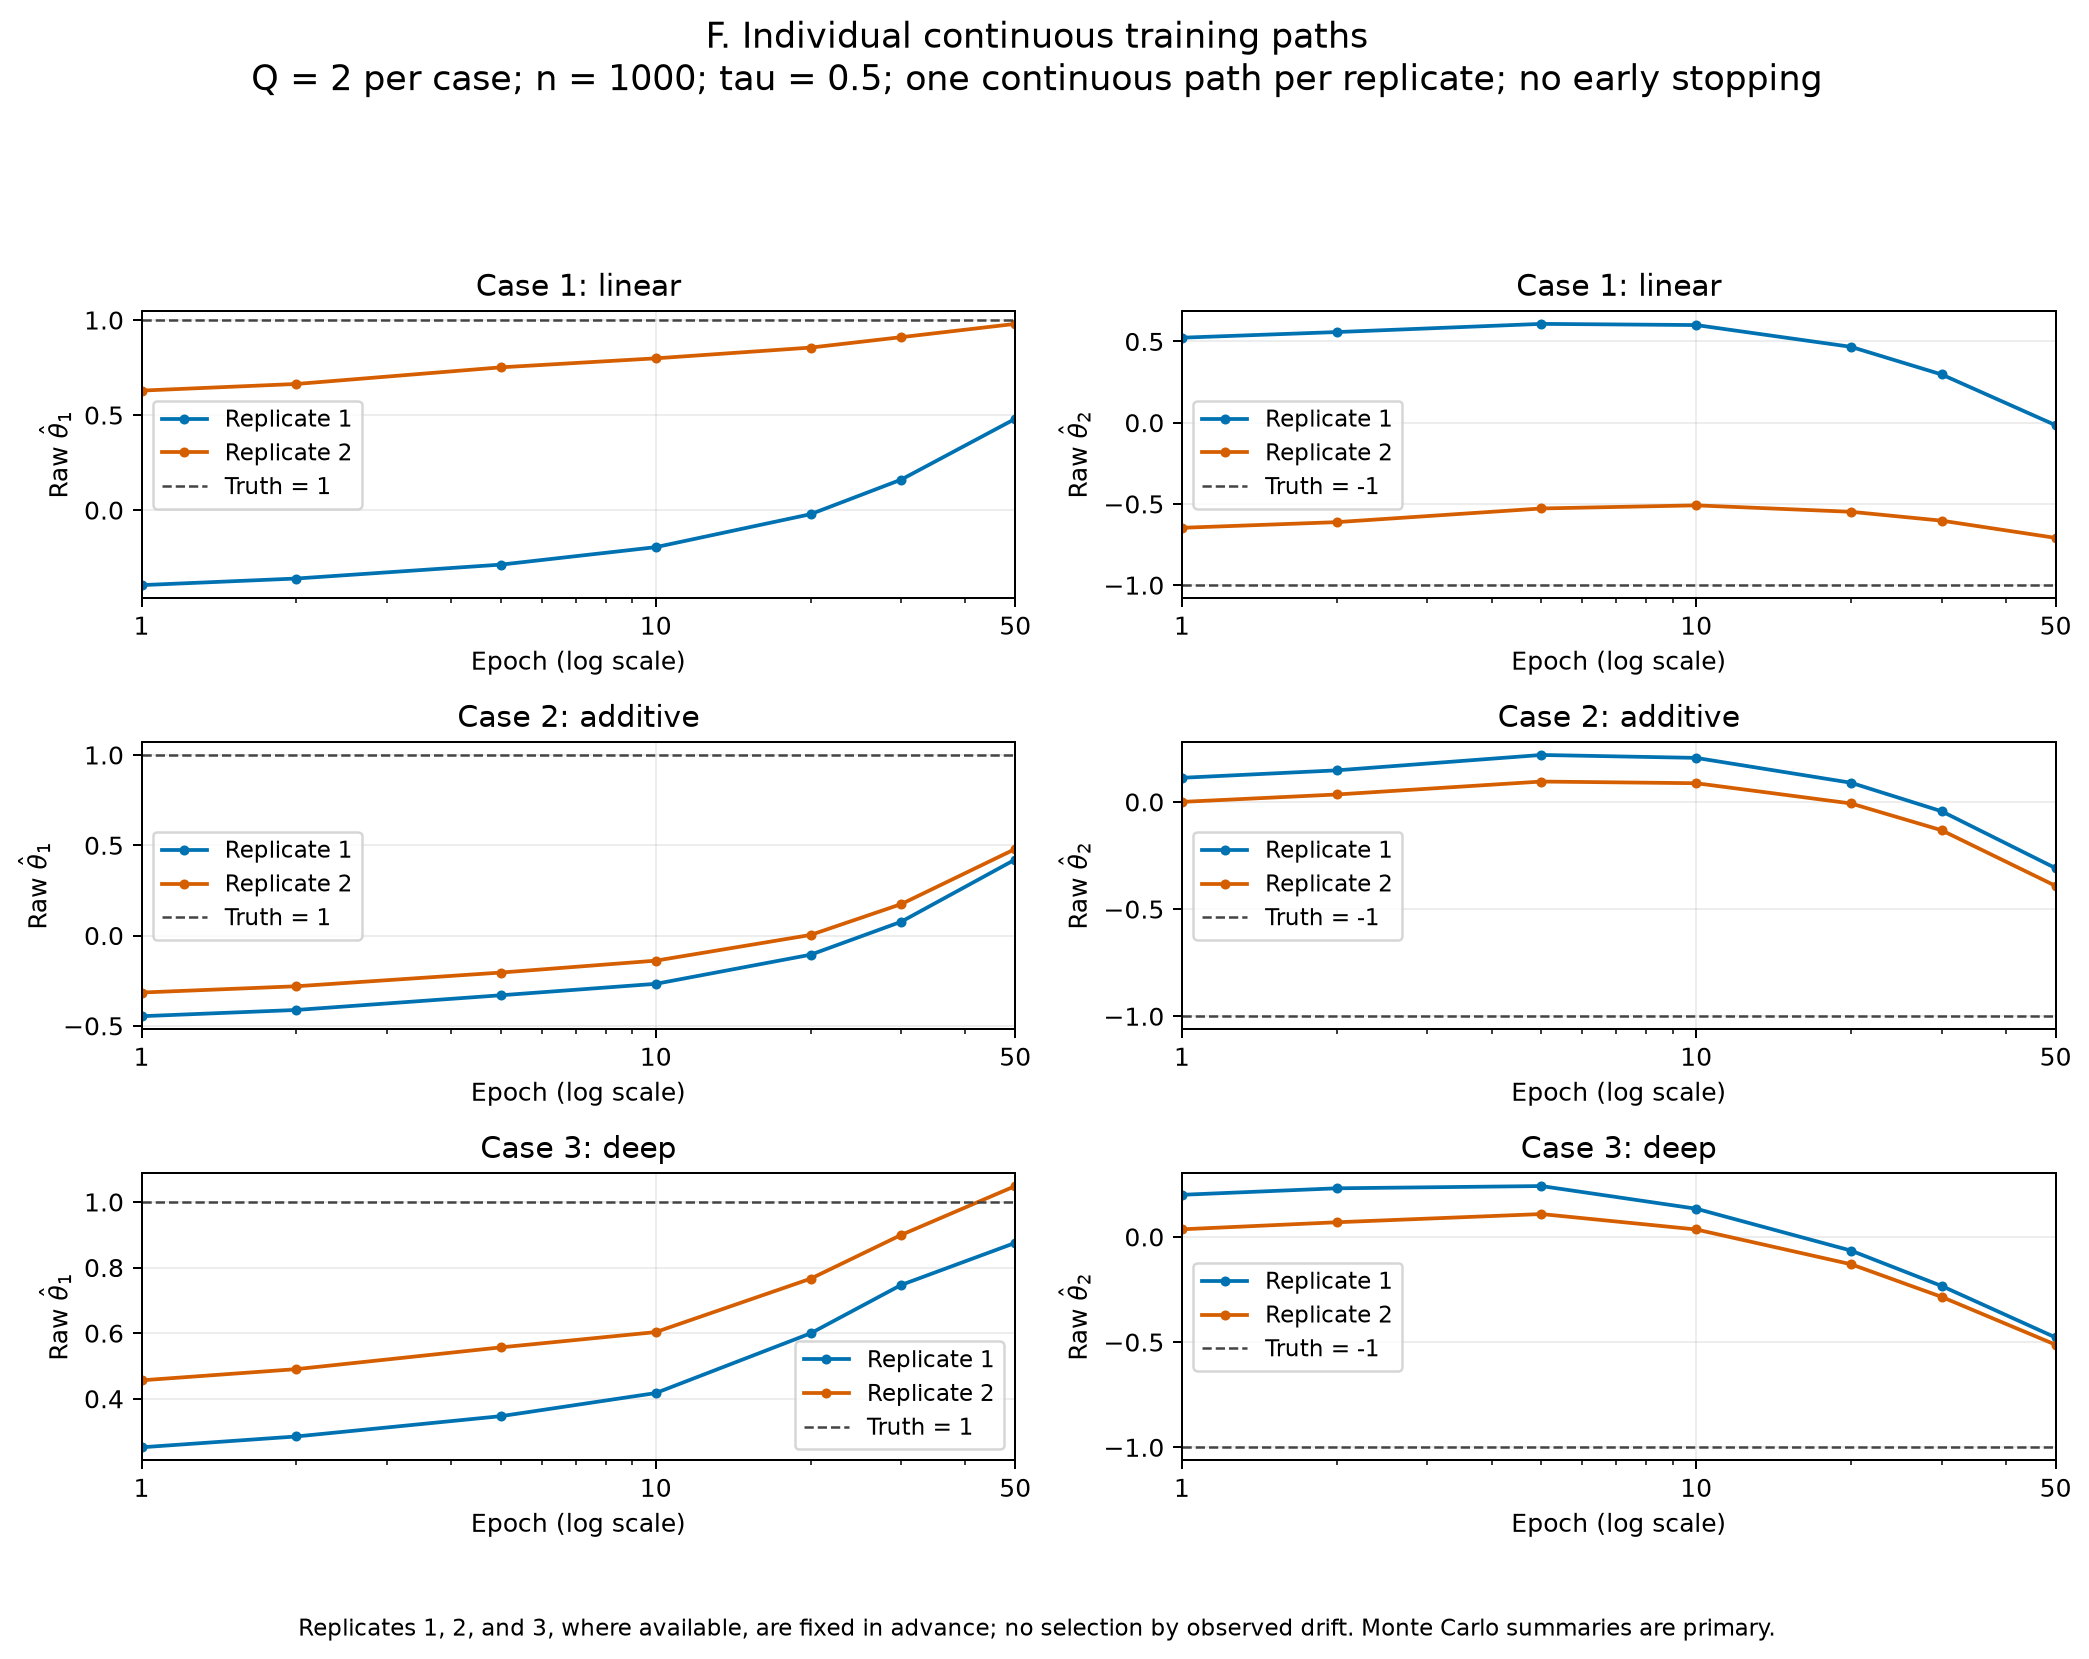

In [4]:
display(pd.read_csv(OUTPUT_DIR/'monte_carlo_summary.csv'))
display(Markdown((OUTPUT_DIR/'RESULTS.md').read_text(encoding='utf-8').split('## Figures')[0]))
for figure in sorted((OUTPUT_DIR/'figures').glob('*.png')):
    display(Markdown('### '+figure.stem.replace('_',' ')))
    display(Image(filename=str(figure)))